## PCA (Principal Component Analysis)

PCA for dimensionality reduction by using SVD decomposition (for memory efficiency since the covariance matrix would be huge, intractable for an high resolution image).

Incremental PCA is used to process the dataset in batches, since the dataset is too large to fit into memory all at once.
___

Import libraries

In [29]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from gripper_data import GripperDataset, plot_image, compute_mean_images, load_images, transpose_channels_last
import os
import sys
import numpy as np
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


Load data and preprocess

In [2]:
top_img_shape = np.array([720, 1280])
resize_factor = 4
resize_shape = [x for x in map(int,top_img_shape/resize_factor)]
print(f"Resizing images to {resize_shape}")
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        transforms.Lambda(lambda x: torch.flatten(x))
        ])
batch_size = 200 #int(os.getenv("BATCH_SIZE"))
print(f"Batch size: {batch_size}")
sessions = np.arange(1,6) # sessions to load
path = os.getenv("DATASET_PATH") # experiment path
dataset = GripperDataset(abs_path=path, sessions=sessions, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

bottom_images, top_images, states = next(iter(dataloader))
print("Image size:", top_images[0].shape)

Resizing images to [180, 320]
Batch size: 200
Image size: torch.Size([172800])


Load mean images

In [2]:
# load mean images

name = "_mean"
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

print("Shape mean bottom image: ", [*mean_bottom.shape])
print("Shape mean top image: ", [*mean_top.shape])
# plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

transform = transforms.Resize(resize_shape)
top_mean = torch.flatten(transform(torch.tensor(mean_top, device=DEVICE)))
# top_mean = torch.flatten(torch.tensor(mean_top, device=DEVICE))

Loading existing mean images
Shape mean bottom image:  [3, 640, 480]
Shape mean top image:  [3, 720, 1280]


NameError: name 'resize_shape' is not defined

PCA and extract eigenvectors

Note: the function partial_fit() is used to fit the model incrementally, processing the data in batches, useful when the dataset is too large to fit into memory all at once. However the batch passed should be at least as big as the number of components to be extracted.

In [4]:
from sklearn.decomposition import IncrementalPCA
import pickle

num_components = batch_size
filename = f'pca_model_{num_components}.pkl'

if os.path.exists(filename):
    print("Loading existing PCA model")
    with open(filename, 'rb') as f:
        pca = pickle.load(f)

else: 
    print("Creating new PCA model")
    pca = IncrementalPCA(batch_size=batch_size, n_components=num_components)

    for batch in tqdm(dataloader, desc="Fitting PCA", total=len(dataloader)):
        bottom_images, top_images, states = batch
        # batch_len = top_images.shape[0]
        # top_images = top_images.reshape(batch_len, -1).numpy() # flatten images

        # apply incremental PCA on the batch
        pca.partial_fit(top_images - top_mean)

    # save pca model
    with open(filename, 'wb') as f:
        pickle.dump(pca, f)

# extract eigenvectors
eigenvectors = pca.components_

Loading existing PCA model


Projection on all the components

Num components: 200
Projections shape: (200, 200)


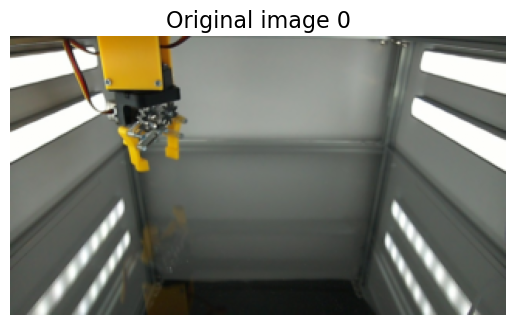

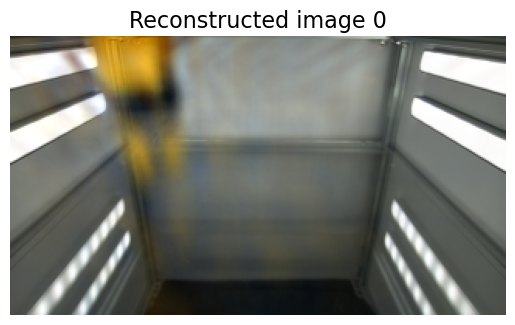

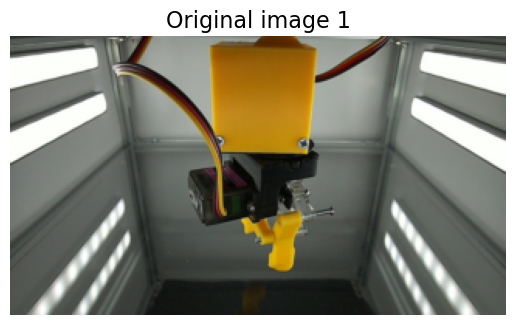

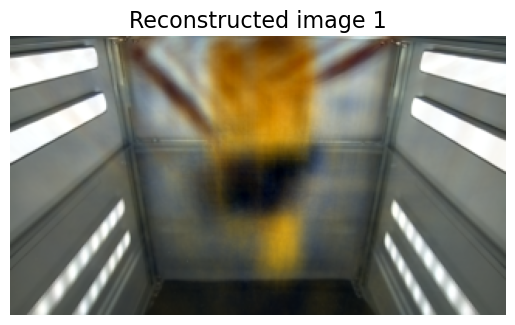

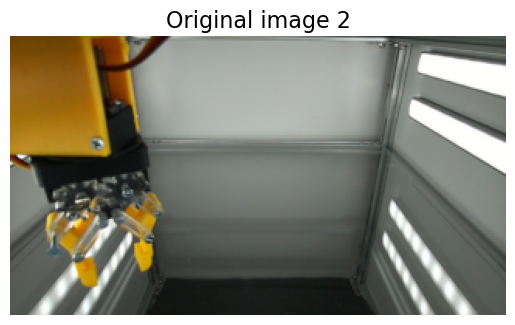

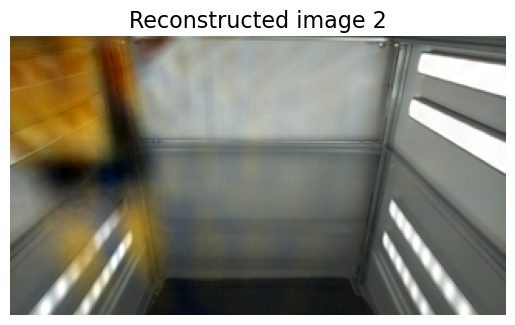

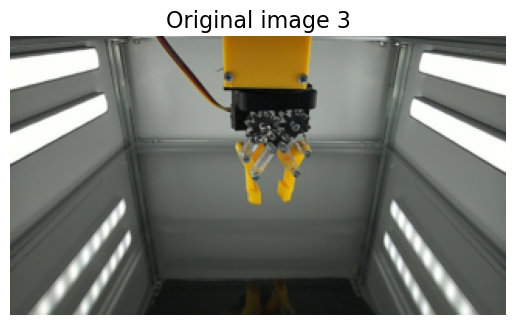

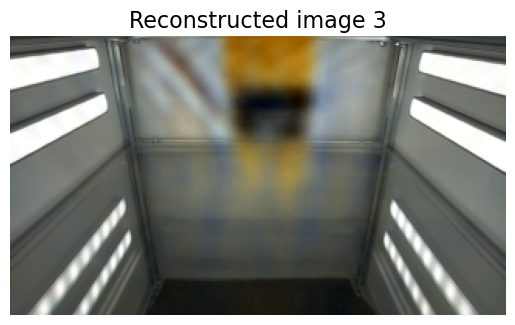

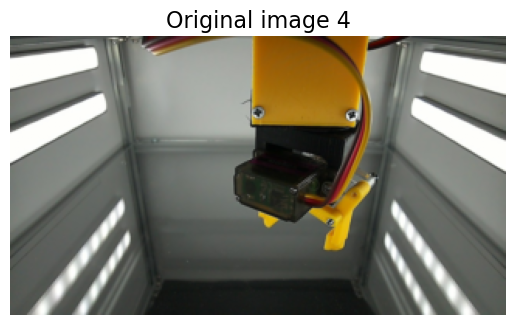

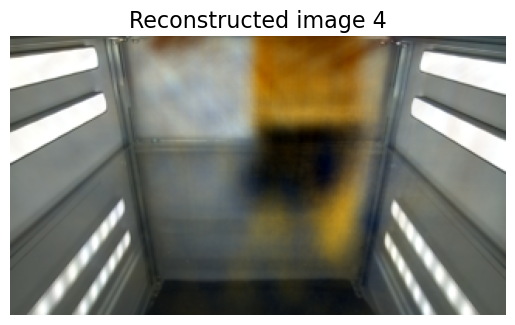

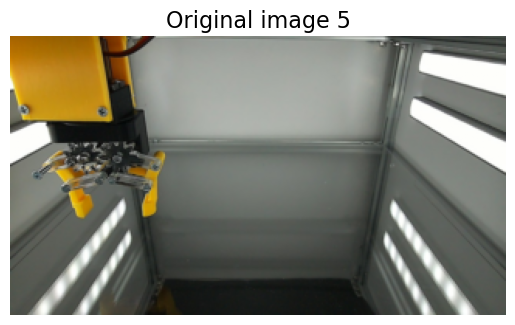

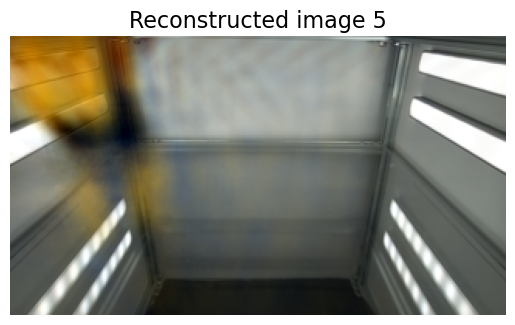

In [ ]:
import matplotlib.pyplot as plt

print("Num components:", pca.n_components_)
batch = next(iter(dataloader))
bottom_images, top_images, states = batch

# Project new data into PCA space
projections = pca.transform(top_images - top_mean)
print("Projections shape:", projections.shape)

# Reconstruct data from projections
reconstructed = pca.inverse_transform(projections) + top_mean.numpy()

i = 0
for reconstruction, img in zip(reconstructed, top_images):
    img = np.reshape(img, (3,resize_shape[0],-1))
    plot_image(img, title=f"Original image {i}")
    reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
    plot_image(reconstruction, title=f"Reconstructed image {i}")
    i += 1
    if i>5:
        break

Select a custom number of components

C:\Users\UTENTE\AppData\Local\Temp\ipykernel_28156\3590430312.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projections = (top_images - top_mean) @ selected_eigenvectors.T


Projections shape: torch.Size([200, 1])


C:\Users\UTENTE\AppData\Local\Temp\ipykernel_28156\3590430312.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reconstructed = projections @ selected_eigenvectors + top_mean.numpy()


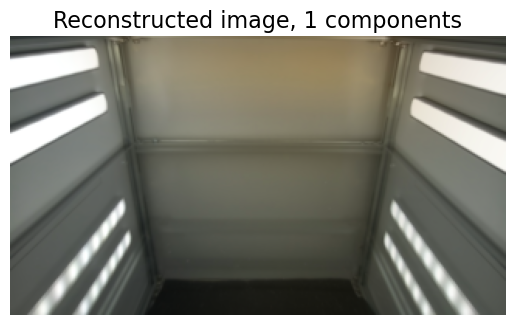

In [7]:
selected_components = 1
eigenvectors = pca.components_
selected_eigenvectors = eigenvectors[:selected_components]

projections = (top_images - top_mean) @ selected_eigenvectors.T
print("Projections shape:", projections.shape)

# Reconstruct data from projections
reconstructed = projections @ selected_eigenvectors + top_mean.numpy()
for reconstruction, img in zip(reconstructed, top_images):
    img = np.reshape(img, (3,resize_shape[0],-1))
    img = transpose_channels_last(img)
    reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
    plot_image(reconstruction,
                title=f"Reconstructed image, {selected_components} components")
    break

Projection on a custom number of components and reconstruction with evaluation of the variance explained by those components.

C:\Users\UTENTE\AppData\Local\Temp\ipykernel_28156\4239849698.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projections = (top_images - top_mean) @ selected_eigenvectors.T
C:\Users\UTENTE\AppData\Local\Temp\ipykernel_28156\4239849698.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reconstructed = projections @ selected_eigenvectors + top_mean.numpy()


Projections shape: torch.Size([200, 1])
Projections shape: torch.Size([200, 2])
Projections shape: torch.Size([200, 10])
Projections shape: torch.Size([200, 50])
Projections shape: torch.Size([200, 100])
Projections shape: torch.Size([200, 200])


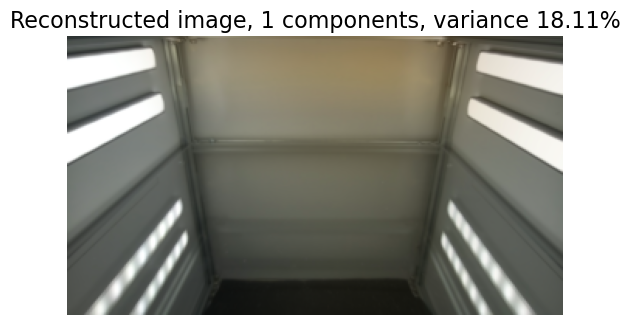

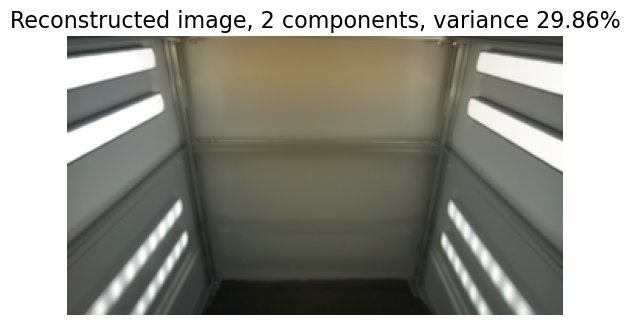

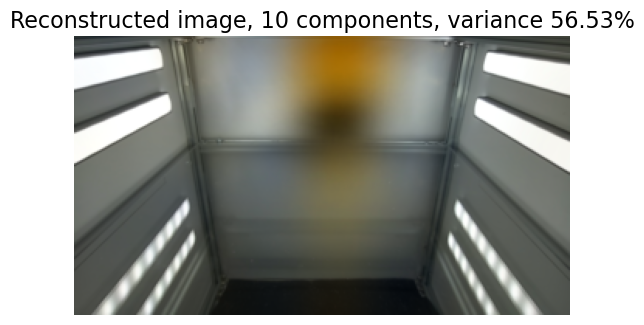

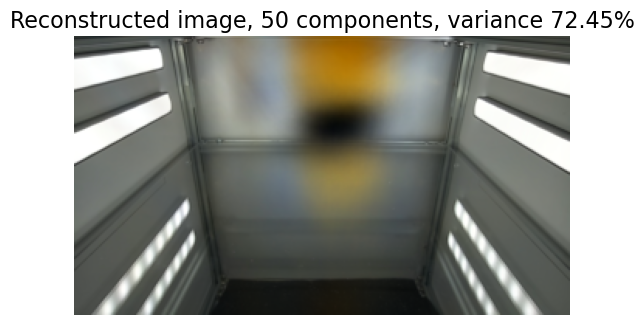

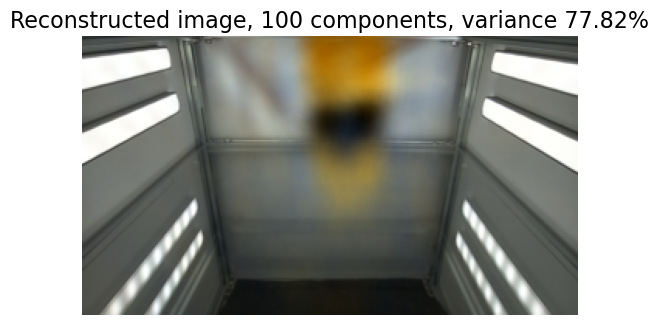

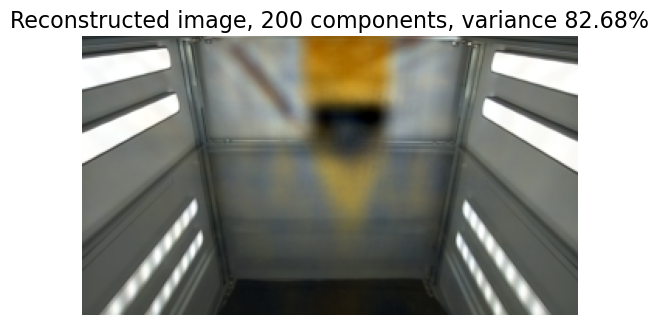

In [14]:
list_num_components = [1, 2, 10, 50, 100, 200]
# fig, ax = plt.subplots(nrows=len(list_num_components), 
#                        figsize=(10, 5*len(list_num_components)))
# ax = ax.flatten()

for selected_components in list_num_components:
    # projection along selected principal components
    selected_eigenvectors = eigenvectors[:selected_components]
    projections = (top_images - top_mean) @ selected_eigenvectors.T
    print("Projections shape:", projections.shape)

    # Variance explained by selected components
    explained_variance = np.sum(pca.explained_variance_ratio_[:selected_components])

    # Reconstruct data from projections
    reconstructed = projections @ selected_eigenvectors + top_mean.numpy()

    # display reconstructed images
    for reconstruction, img in zip(reconstructed, top_images):
        img = np.reshape(img, (3,resize_shape[0],-1))
        img = transpose_channels_last(img)
        reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
        plot_image(reconstruction,
                   title=f"Reconstructed image, {selected_components} components, "
                   f"variance {explained_variance*100:.2f}%")
                #    ax=ax[list_num_components.index(selected_components)])
        # plt.figure()
        # plt.imshow(img.numpy())
        break

Variance (percentage) and cumulative variance explained by the components. The variance decreases exponentially fast.

Variance explained by 1 components: 18.11%
Variance explained by 2 components: 29.86%
Variance explained by 3 components: 37.47%
Variance explained by 4 components: 42.65%
Variance explained by 5 components: 47.38%
Variance explained by 6 components: 50.30%
Variance explained by 7 components: 52.10%
Variance explained by 8 components: 53.72%
Variance explained by 9 components: 55.22%
Variance explained by 10 components: 56.53%
Variance explained by 11 components: 57.81%
Variance explained by 12 components: 58.85%
Variance explained by 13 components: 59.73%
Variance explained by 14 components: 60.57%
Variance explained by 15 components: 61.32%
Variance explained by 16 components: 61.96%
Variance explained by 17 components: 62.56%
Variance explained by 18 components: 63.15%
Variance explained by 19 components: 63.72%
Variance explained by 20 components: 64.26%
Variance explained by 21 components: 64.73%
Variance explained by 22 components: 65.17%
Variance explained by 23 components: 65.6

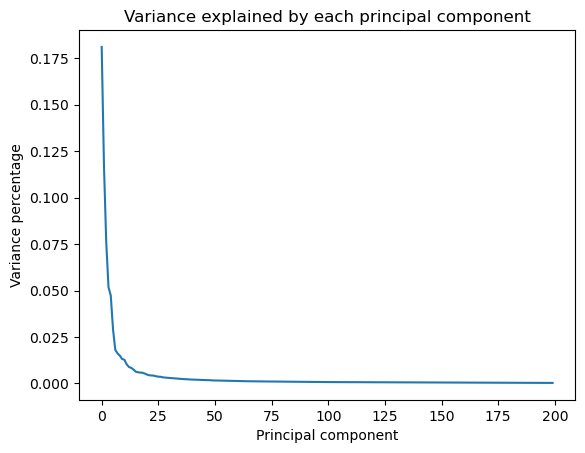

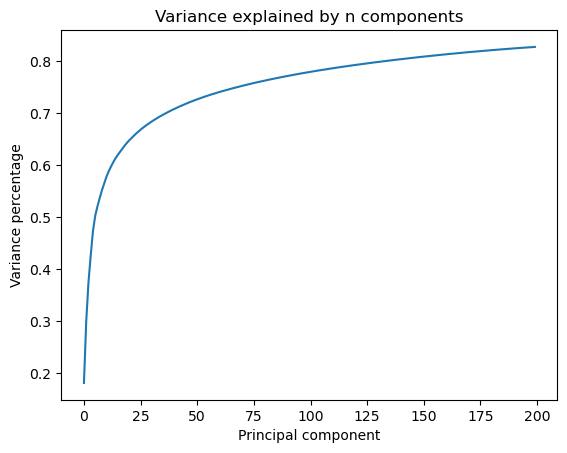

In [20]:
import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_
plt.plot(explained_variance)
plt.xlabel("Principal component") 
plt.ylabel("Variance percentage")
plt.title("Variance explained by each principal component")

plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Principal component") 
plt.ylabel("Variance percentage")
plt.title("Variance explained by n components")

for i in range(len(explained_variance)):
    print(f"Variance explained by {i+1} components: {np.sum(explained_variance[:i+1])*100:.2f}%")

### PCA on masks

In [30]:
top_img_shape = np.array([720, 1280])
resize_factor = 4
resize_shape = [x for x in map(int,top_img_shape/resize_factor)]
print(f"Resizing images to {resize_shape}")
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        transforms.Lambda(lambda x: torch.flatten(x))
        ])
batch_size = 200 #int(os.getenv("BATCH_SIZE"))
print(f"Batch size: {batch_size}")
sessions = np.arange(1,3) # sessions to load
path = os.getenv("DATASET_PATH") # experiment path
dataset = GripperDataset(abs_path=path, sessions=sessions, transform=preprocess,
                         images_to_load=["Top_masks_processed"])
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

top_masks, states = next(iter(dataloader))
print("Image size:", top_masks[0].shape)

Resizing images to [180, 320]
Batch size: 200
Image size: torch.Size([57600])


In [31]:
from gripper_data import load_image, compute_mean_image, plot_image

filename = os.path.join("clean_environment_images","mean_mask.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(filename):
    print("Loading existing image")
    top_mean = load_image(filename).squeeze()
else:
    print("Calculating mean image")
    top_mean = compute_mean_image(dataset, name=filename)

print("Shape mean top image: ", [*top_mean.shape])
# plot_image(mean_mask_top, title="Mean mask, clean environment")

Calculating mean image


100%|██████████| 4767/4767 [00:35<00:00, 133.80it/s]

Storing mean image clean_environment_images\mean_mask.jpeg
Shape mean top image:  [57600]


In [ ]:
from sklearn.decomposition import IncrementalPCA
import pickle

num_components = batch_size
filename = f'pca_masks_{num_components}.pkl'

if os.path.exists(filename):
    print("Loading existing PCA model")
    with open(filename, 'rb') as f:
        pca = pickle.load(f)

else: 
    print("Creating new PCA model")
    pca = IncrementalPCA(batch_size=batch_size, n_components=num_components)

    for batch in tqdm(dataloader, desc="Fitting PCA", total=len(dataloader)):
        top_images, states = batch
        # apply incremental PCA on the batch
        # pca.partial_fit(top_images)
        pca.partial_fit(top_images.numpy() - top_mean)

    # save pca model
    with open(filename, 'wb') as f:
        pickle.dump(pca, f)

# extract eigenvectors
eigenvectors = pca.components_

Loading existing PCA model


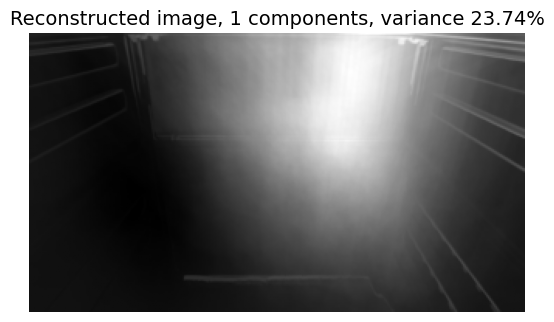

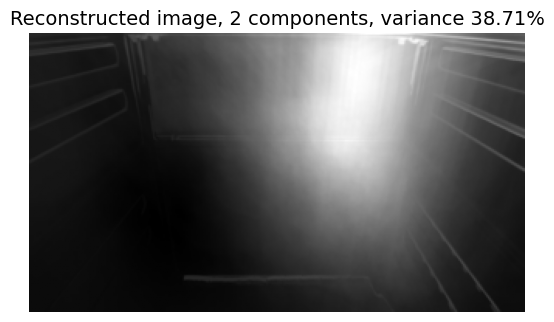

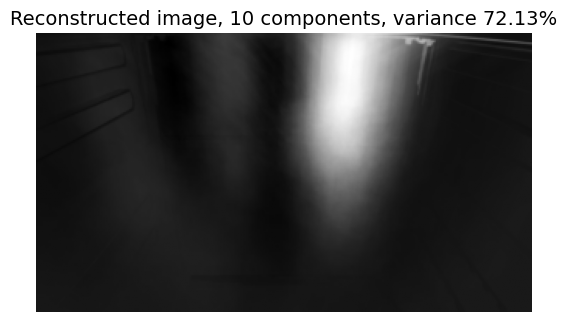

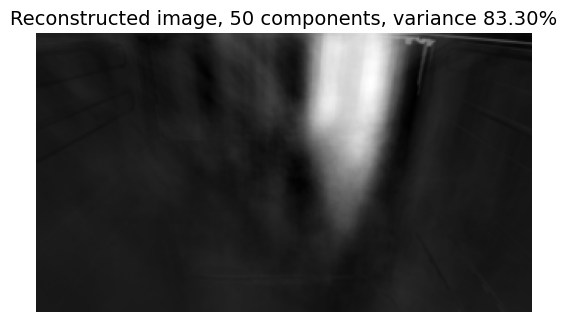

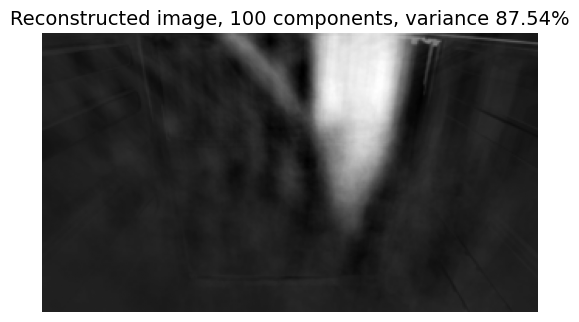

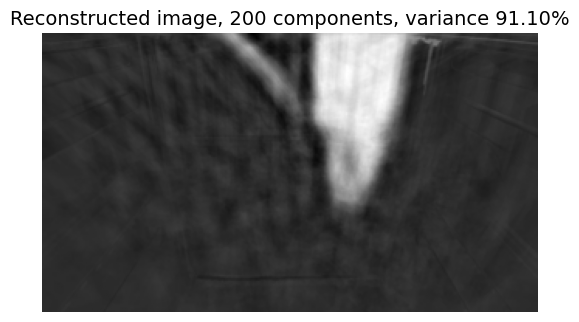

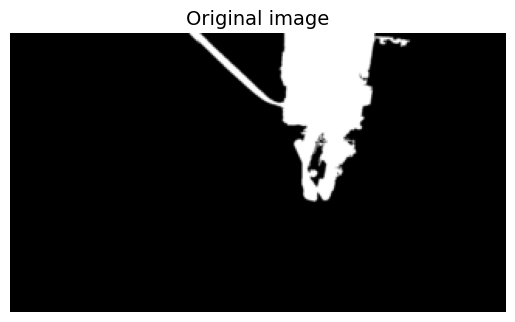

In [58]:
list_num_components = [1, 2, 10, 50, 100, 200]
# top_images, _ = next(iter(dataloader))

for selected_components in list_num_components:
    # projection along selected principal components
    selected_eigenvectors = eigenvectors[:selected_components]
    projections = (top_images - top_mean) @ selected_eigenvectors.T
    # print("Projections shape:", projections.shape)

    # Variance explained by selected components
    explained_variance = np.sum(pca.explained_variance_ratio_[:selected_components])

    # Reconstruct data from projections
    reconstructed = projections @ selected_eigenvectors + top_mean

    # display reconstructed images
    for reconstruction, img in zip(reconstructed, top_images):
        img = np.reshape(img, (resize_shape[0],-1))
        img = transpose_channels_last(img)
        reconstruction = np.reshape(reconstruction, (resize_shape[0],-1))
        plot_image(reconstruction,
                   title=f"Reconstructed image, {selected_components} components, "
                   f"variance {explained_variance*100:.2f}%")
                #    ax=ax[list_num_components.index(selected_components)])
        break

plot_image(img, title=f"Original image")

Variance explained by 1 components: 23.74%
Variance explained by 2 components: 38.71%
Variance explained by 3 components: 48.45%
Variance explained by 4 components: 56.09%
Variance explained by 5 components: 61.97%
Variance explained by 6 components: 65.59%
Variance explained by 7 components: 67.88%
Variance explained by 8 components: 69.65%
Variance explained by 9 components: 71.01%
Variance explained by 10 components: 72.13%
Variance explained by 11 components: 73.11%
Variance explained by 12 components: 73.80%
Variance explained by 13 components: 74.36%
Variance explained by 14 components: 74.91%
Variance explained by 15 components: 75.39%
Variance explained by 16 components: 75.82%
Variance explained by 17 components: 76.25%
Variance explained by 18 components: 76.62%
Variance explained by 19 components: 76.97%
Variance explained by 20 components: 77.32%
Variance explained by 21 components: 77.64%
Variance explained by 22 components: 77.94%
Variance explained by 23 components: 78.2

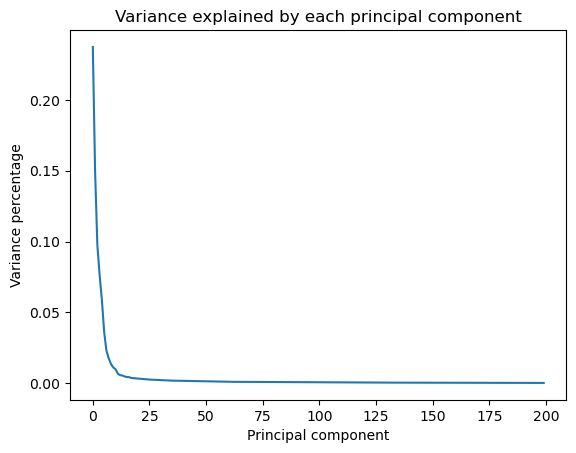

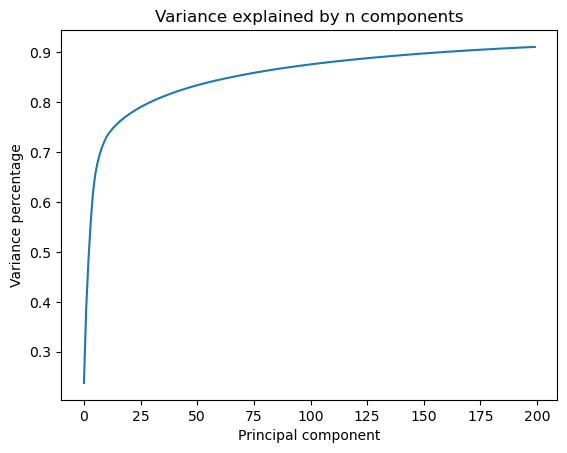

In [43]:
import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_
plt.plot(explained_variance)
plt.xlabel("Principal component") 
plt.ylabel("Variance percentage")
plt.title("Variance explained by each principal component")

plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Principal component") 
plt.ylabel("Variance percentage")
plt.title("Variance explained by n components")

for i in range(len(explained_variance)):
    print(f"Variance explained by {i+1} components: {np.sum(explained_variance[:i+1])*100:.2f}%")